# Full Submission Code

Chromatic TDA code taken from https://github.com/OnDraganov/chromatic-tda/blob/main/manual.ipynb

# Imports and definitions

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import chromatic_tda as chro
import random
from matplotlib.collections import LineCollection
import json

print(f'Loaded chromatic_tda version {chro.__version__}')

Loaded chromatic_tda version 1.1.8


# Plot Tumor Dataset
## Region T_E_ROI_29

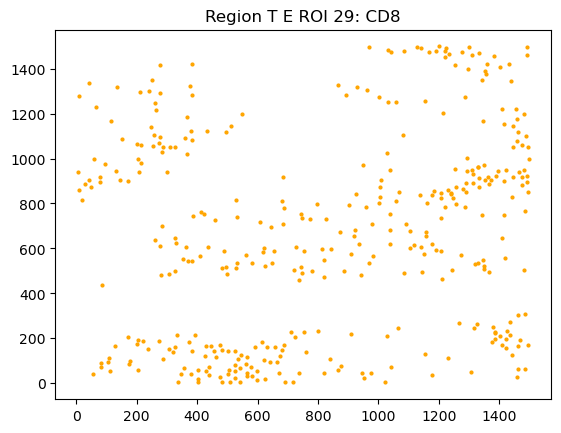

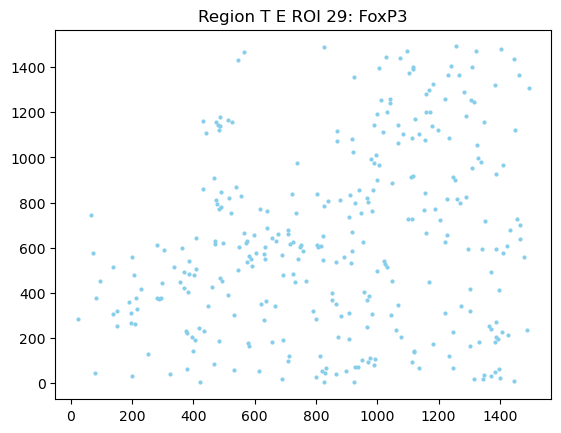

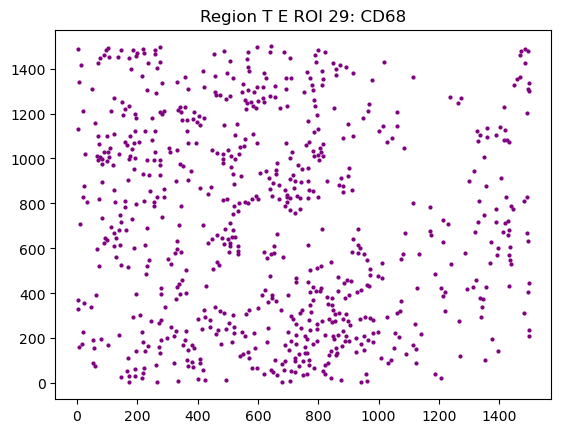

In [59]:
dataPath = os.path.join(os.getcwd(), "1.5mmRegions")

plotPath = os.path.join(os.getcwd(), "plots")
if not os.path.exists(plotPath):
    os.makedirs(plotPath)

regionBaseName = "T_E_ROI_29_locations_"
clouds = [
    {"name": "CD8", "color": "orange", "points": []},
    {"name": "FoxP3", "color": "skyblue", "points": []},
    {"name": "CD68", "color": "purple", "points": []},
]

def read_csv(csvPath):
    # print(f"read_csv called on file {csvPath}")

    # read in the csv file as a list of point coordinates and return the list
    fileText = ''
    with open(csvPath, "r") as file:
        fileText = file.read()

    lines = fileText.split('\n')
    points = []
    for line in lines:
        try:
            coord = [float(e) for e in line.split(',')]
            points.append(coord)
        except:
            # print(f'{line} is not a valid coordinate')
            continue

    return points

for cloud in clouds:
    fileName = regionBaseName + cloud["name"] + '.csv'
    filePath = os.path.join(dataPath, cloud["name"], fileName)

    # print(f'loading point cloud data: {filePath}...')

    if not os.path.isfile(filePath):
        print(f"Could not find point cloud {filePath}")
        continue

    points = np.array(read_csv(filePath))
    # print(f'\tcloud data shape: {points.shape}')
    # pprint(points)

    plotImage = os.path.join(plotPath, f'{regionBaseName}{cloud["name"]}.png')

    fig = plt.figure(1)
    plt.title(f'Region T E ROI 29: {cloud["name"]}')
    plt.scatter(points[:, 0], points[:, 1], color=cloud["color"], s=4)
    # plt.savefig(plotImage)
    plt.show()
    plt.close()

    # print(f'\tpoint cloud figure saved to: {plotImage}')

    cloud["points"] = points
    print()

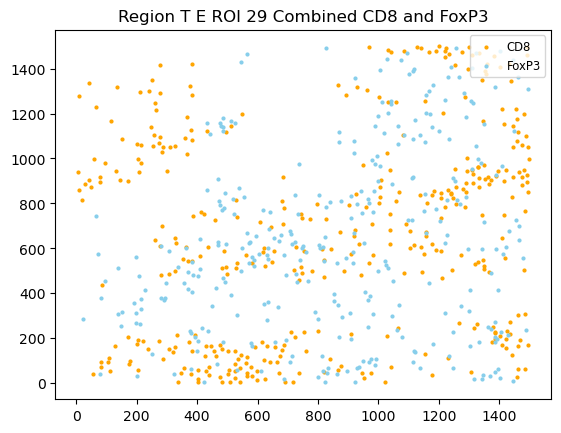

In [60]:
cd8 = [e for e in clouds if e["name"] == "CD8"][0]
cd68 = [e for e in clouds if e["name"] == "CD68"][0]
foxp3 = [e for e in clouds if e["name"] == "FoxP3"][0]

plotImage = os.path.join(plotPath, f'{regionBaseName}combined_CD8_FoxP3.png')

fig = plt.figure(1)
plt.title(f'Region T E ROI 29 Combined CD8 and FoxP3')

plt.scatter(cd8["points"][:, 0], cd8["points"][:, 1], color=cd8["color"], s=4, label=cd8["name"])
plt.scatter(foxp3["points"][:, 0], foxp3["points"][:, 1], color=foxp3["color"], s=4, label=foxp3["name"])

plt.legend(loc='upper right', shadow=False, ncols=1, fontsize='small')
plt.show()
# plt.savefig(plotImage)

# print(f'point cloud figure saved to: {plotImage}')

# Chromatic TDA

## Load data

In [43]:
# Rearrange data for chromatic_tda library
cd8points = cd8["points"].tolist()
foxp3points = foxp3["points"].tolist()
points = cd8points + foxp3points
labels = [ 1 for _ in cd8points ]
labels.extend( [ 0 for _ in foxp3points ] )

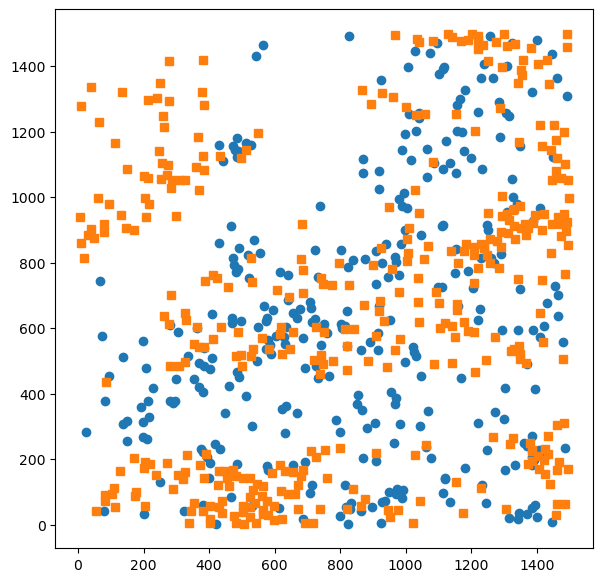

In [44]:
# Plot data
chro.plot_labeled_point_set(points, labels)
plt.show()

## From chromatic point cloud to a six-pack of persistence diagrams

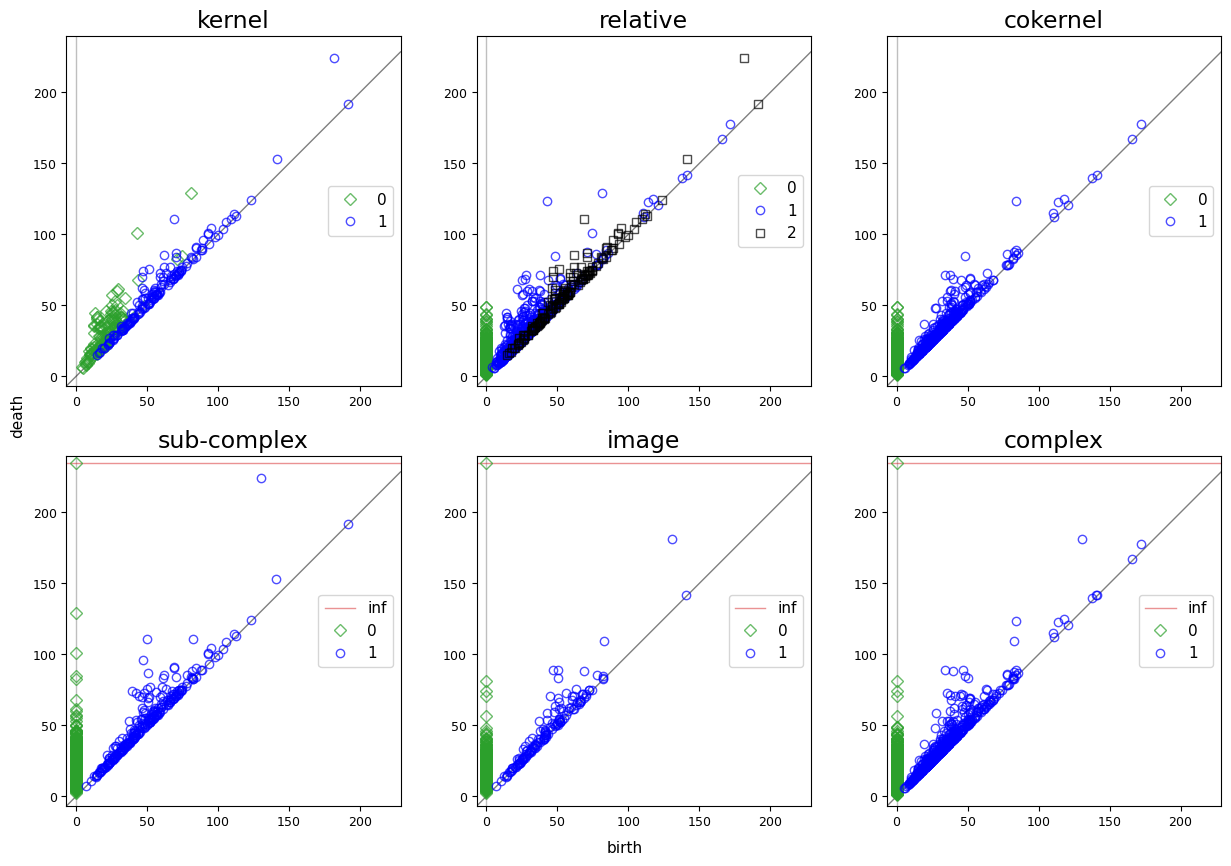

In [45]:
# Compute the chromatic Delaunay complex and extract the subcomplex-complex pair
alpha_complex = chro.ChromaticAlphaComplex(points, labels)
simplicial_complex = alpha_complex.get_simplicial_complex(sub_complex='0') # "0-labeled into all"

# Compute persistence, and show the six pack
simplicial_complex.compute_persistence() # optional, would be called automatically below
chro.plot_six_pack(simplicial_complex)
plt.show()

Both `plot_six_pack` and `plot_persistence_diagram` functions in `chromatic_tda` return the figure and axes, and can also take many keyword arguments from the `matplotlib`. Below is an example of a customised six pack plot.

In [ ]:
fig, axs = chro.plot_six_pack(simplicial_complex,
                   size=6,
                   title_fontsize=30,
                   ticks_fontsize=12,
                   legend_fontsize=16,
                   marker={0:'^', 1:'d'},
                   color={0:'red', 1:'green', 2:'tab:orange'},
                   fillstyle='full',
                   markersize=12,
                   alpha=.4,
                   axes_labels=False)
axs[2].set_visible(False)
axs[5].set_visible(False)
fig.suptitle("Customised six-pack plot", fontsize=35, x=0.3)
plt.show()

# Experimental: Feature extraction (get loops back from diagrams)

A very important aspect of using persistence homology is going back to data and interpret the identified features.

One caveat is that a "feature" is not a single loop, but a class of loops, and even worse, this class is a "dimension" of a vector space rather than a concrete element of it. This means that there is many options for "the loop that corresponds to a persistence bar".

While there is no single cannonical choice, there are some choices that are meaningful and easy to obtain from the computations we perform. Below we show how to extract and plot a loop.

## Set up

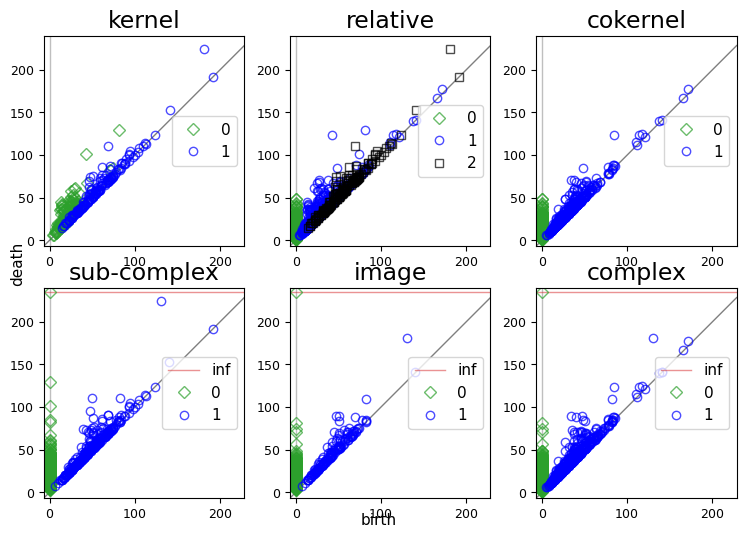

In [46]:
# Set up the complexes, compute persistence and show the six-pack
alpha = chro.ChromaticAlphaComplex(points, labels)
simplicial_complex = alpha.get_simplicial_complex(sub_complex='0')
chro.plot_six_pack(simplicial_complex, size = 3)
plt.show()

In [47]:
# We set up the feature extractor
feature_extractor = chro.experimental.feature_extraction.FeatureExtractor(simplicial_complex)

## Most persistent features

In [48]:
# Let's first plot the three largest loops in the 'complex' diagram
# We extract persistence pairs as the simplices giving birth and death (rather than the birth-death values).
# We let them be sorted by 'persistence', that is, by the length of the correxponding bars. This is the default option.
# We take the three most persistant.
top_three_features = feature_extractor.persistence_pairs(group='complex', dim=1, sorted_by='persistence')[:3]
top_three_features

[((342, 671), (282, 611, 619)),
 ((469, 526), (133, 195, 464)),
 ((209, 562), (409, 416, 421))]

In [49]:
# We extract corresponding loops
loops = [feature_extractor.extract_feature(death, group='complex') for birth, death in top_three_features]

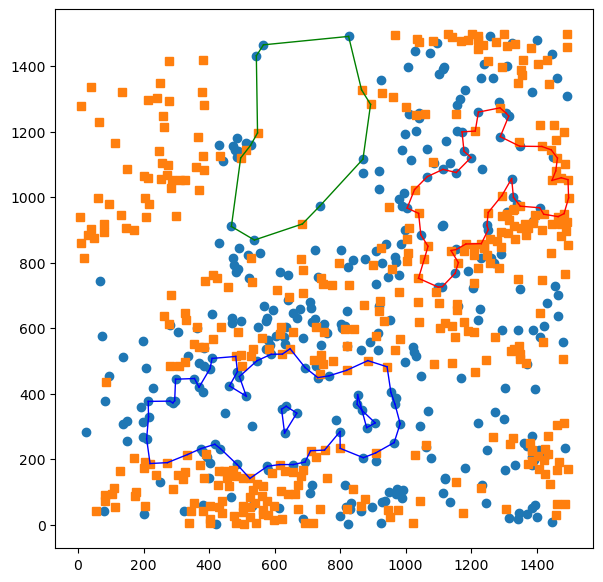

In [50]:
# Finally, we plot the three features in red, green and blue, into the point set plot.
# Note that each line outputs the axis, and we pass it in the ax argument of the next line.
fig, ax = chro.plot_labeled_point_set(points, labels)
fig, ax = chro.plot_edges(points, loops[0], ax=ax, color='red')
fig, ax = chro.plot_edges(points, loops[1], ax=ax, color='green')
fig, ax = chro.plot_edges(points, loops[2], ax=ax, color='blue')
plt.show()

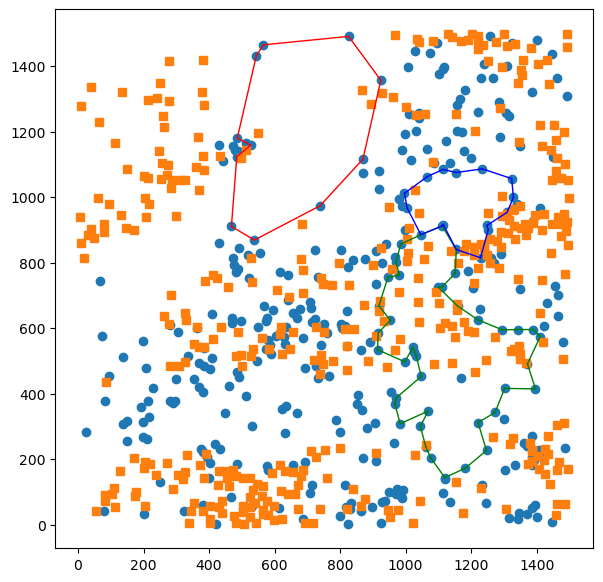

In [51]:
# Now we do the same for the blue sub-complex
top_three_features = feature_extractor.persistence_pairs(group='sub_complex', dim=1, sorted_by='persistence')[:3]
loops = [feature_extractor.extract_feature(death, group='sub_complex') for birth, death in top_three_features]
fig, ax = chro.plot_labeled_point_set(points, labels)
fig, ax = chro.plot_edges(points, loops[0], ax=ax, color='red')
fig, ax = chro.plot_edges(points, loops[1], ax=ax, color='green')
fig, ax = chro.plot_edges(points, loops[2], ax=ax, color='blue')
plt.show()

## Particular feature from a diagram

If we want to extract a particular feature from a diagram, we can identify it with the birth-death coordinates. We can either get the coordinates directly from `simplicial_complex.bars(...)` or guess a nearby value. Either way we can get persistence pairs sorted by the proximity from those coordinates in the diagram.

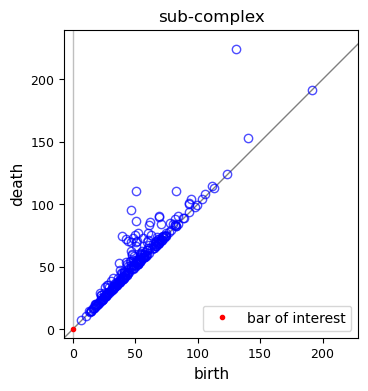

In [52]:
# our guess of where the middle of the three large features in the sub-complex diagram are

bar_of_interest = [0.15, 0.33]

chro.plot_persistence_diagram(simplicial_complex.bars('sub_complex', 1), size=4, color='blue')
plt.plot(*bar_of_interest, linestyle='none', marker='o', markersize=3, color='red', label='bar of interest')
plt.legend()
plt.title('sub-complex')
plt.show()

In [53]:
# Now we extract the pair with birth-death value the closest to the defined:
pair = feature_extractor.persistence_pairs('sub_complex', 1, sorted_by='proximity', bar_of_interest=[0.15, 0.33])[0]

In [54]:
# We can also check the values:
(simplicial_complex.weight_function(pair[0]), simplicial_complex.weight_function(pair[1]))

(np.float64(6.778412168622762), np.float64(7.072195077287721))

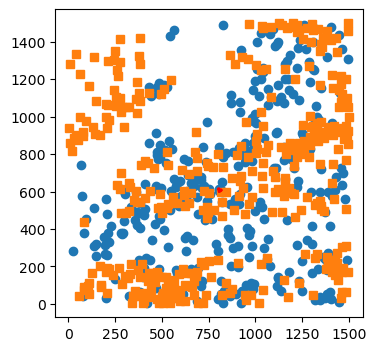

In [55]:
# Finally, we extract the loop and plot it
loop = feature_extractor.extract_feature(pair[1], 'sub_complex')
fig, ax = chro.plot_labeled_point_set(points, labels, size=4)
chro.plot_edges(points, loop, ax=ax, color='red', linewidth=2)
plt.show()

We can see that it is the one that is not filled by orange points at all---this makes sense looking back at the six-pack, where we see that the same dots appears also in the image and complex diagrams. We can extract the same feature from those diagrams and visually compare.

In this example, indeed, they all overlap. This might not be the case even if it is still the same feature, due to the freedom of choice of a loop representative, as mentioned in the intro to this section.

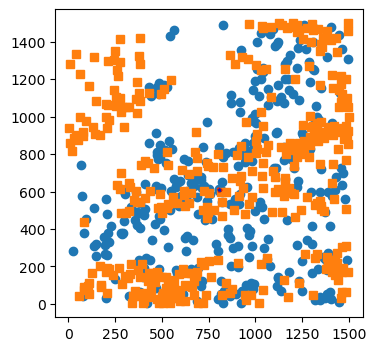

In [56]:
pair_sub = feature_extractor.persistence_pairs('sub_complex', 1, sorted_by='proximity', bar_of_interest=[0.15, 0.33])[0]
loop_sub = feature_extractor.extract_feature(pair[1], 'sub_complex')

pair_im = feature_extractor.persistence_pairs('image', 1, sorted_by='proximity', bar_of_interest=[0.15, 0.33])[0]
loop_im = feature_extractor.extract_feature(pair[1], 'image')

pair_cplx = feature_extractor.persistence_pairs('complex', 1, sorted_by='proximity', bar_of_interest=[0.15, 0.33])[0]
loop_cplx = feature_extractor.extract_feature(pair[1], 'complex')

# Finally, we extract the loop and plot it
loop = feature_extractor.extract_feature(pair[1], 'sub_complex')
fig, ax = chro.plot_labeled_point_set(points, labels, size=4)
fig, ax = chro.plot_edges(points, loop_sub, ax=ax, color='red', linewidth=2, alpha=.5)
fig, ax = chro.plot_edges(points, loop_im, ax=ax, color='green', linewidth=2, linestyle='--', alpha=.5)
fig, ax = chro.plot_edges(points, loop_cplx, ax=ax, color='blue', linewidth=2, linestyle=':', alpha=.5)
plt.show()

## Kernel

Lastly, we move to kernel, and check that the two largest kernel features are the one completely filled and the one partially filled by orange points.

In [57]:
top_two_kernel_pairs = feature_extractor.persistence_pairs('kernel', 1)[:2]
loops = [feature_extractor.extract_feature(pair[1], 'kernel') for pair in top_two_kernel_pairs]

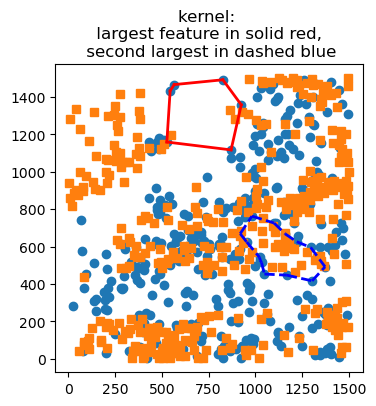

In [58]:
# Finally, we extract the loop and plot it
loop = feature_extractor.extract_feature(pair[1], 'sub_complex')
fig, ax = chro.plot_labeled_point_set(points, labels, size=4)
chro.plot_edges(points, loops[0], ax=ax, color='red', linewidth=2)
chro.plot_edges(points, loops[1], ax=ax, color='blue', linestyle='--', linewidth=2)
plt.title('kernel: \n largest feature in solid red, \n second largest in dashed blue')
plt.show()